<a href="https://colab.research.google.com/github/Bossporrawat/dataforcs372/blob/main/CS372_MiniProject1_%E0%B8%9B%E0%B8%A3%E0%B8%A7%E0%B8%A3%E0%B8%A3%E0%B8%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section Import

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, accuracy_score

# Section 1 นำเข้าข้อมูลจาก github

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def get_raw_github_url(github_blob_url):
    if "github.com" in github_blob_url and "/blob/" in github_blob_url:
        return github_blob_url.replace("github.com", "raw.githubusercontent.com").replace("/blob/", "/")
    return github_blob_url

github_file_url = 'https://github.com/Bossporrawat/dataforcs372/blob/main/cardata.csv' # <<< กรุณาแทนที่ด้วยลิงก์ GitHub ของไฟล์ CSV ของคุณ
url = get_raw_github_url(github_file_url)
df = pd.read_csv(url)

# 2. สำรวจข้อมูลเบื้องต้น
print("--- Data Info ---")
print(df.info())
print("\n--- Missing Values ---")
print(df.isnull().sum())
display(df.head())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None

--- Missing Values ---
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


# Section 2 จัดการข้อมูล (Data Preprocessing)

In [80]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. จัดการ Missing Value (เช่น แทนที่ด้วยค่า Median หรือลบทิ้ง)
df = df.fillna(df.median(numeric_only=True))

# 2. Encoding (เปลี่ยน Categorical เป็น Numerical)
le_features = LabelEncoder() # ใช้ LabelEncoder แยกสำหรับ features
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le_features.fit_transform(df[col])

# 3. Define X and y
X = df.iloc[:, :-1]
y = df.iloc[:, -1] # 'Owner' column is the target

# 4. Encode target variable y to ensure 0-indexed contiguous labels for models like XGBoost
# This step is crucial because XGBoost expects labels 0, 1, 2, ...
le_target = LabelEncoder() # ใช้ LabelEncoder แยกสำหรับ target
y = le_target.fit_transform(y)

# 5. Scaling (สำคัญมากสำหรับ KNN และ Neural Network)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Preprocessing Completed. Data scaled and encoded.")

Preprocessing Completed. Data scaled and encoded.


# Section 3 การเลือกคุณลักษณะ (Feature Selection & Importance)

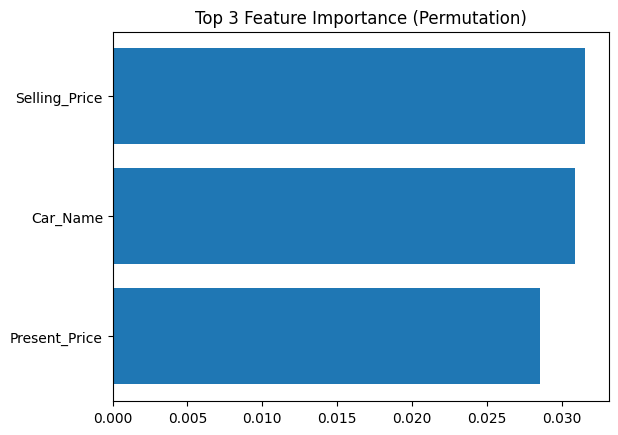

In [81]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# 1. ใช้ Random Forest เป็นตัวแทน Tree-based เพื่อหาความสำคัญ
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_scaled, y)

# 2. คำนวณ Permutation Importance
result = permutation_importance(model_rf, X_scaled, y, n_repeats=10, random_state=42)

# 3. พล็อตกราฟ Top 3
sorted_idx = result.importances_mean.argsort()[-3:] # ดึง Top 3
plt.barh(X.columns[sorted_idx], result.importances_mean[sorted_idx])
plt.title("Top 3 Feature Importance (Permutation)")
plt.show()

# วิเคราะห์: อธิบายในรายงานว่า 3 ตัวนี้เกี่ยวเนื่องกับคลาสอย่างไร

# Section 4 การแบ่งข้อมูล (Experimental Design)

In [82]:
from sklearn.model_selection import train_test_split

# แบ่งเป็น Cross Validation Set (80%) และ Evaluation Set (20%)
# ข้อผิดพลาดเกิดจาก 'stratify=y' ไม่สามารถทำงานได้หากมีคลาสใน 'y' ที่มีจำนวนสมาชิกน้อยกว่า 2 (เช่น มีแค่ 1 ตัวอย่าง)
# เพื่อแก้ไขเบื้องต้น เราจะลบ 'stratify=y' ออกไปก่อน เพื่อให้การแบ่งข้อมูลทำงานได้
X_train_cv, X_eval, y_train_cv, y_eval = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42 #, stratify=y # คอมเมนต์ส่วนนี้ออก
)

print(f"Train/Val set size: {X_train_cv.shape}")
print(f"Evaluation set size: {X_eval.shape}")

# ตรวจสอบการกระจายตัวของคลาสใน 'y' เพื่อทำความเข้าใจปัญหา
print("\nValue counts for target variable (y):")
# แก้ไข: เนื่องจาก y เป็น numpy array จึงต้องแปลงเป็น pandas Series หรือใช้ numpy.unique
print(pd.Series(y).value_counts())

Train/Val set size: (240, 8)
Evaluation set size: (61, 8)

Value counts for target variable (y):
0    290
1     10
2      1
Name: count, dtype: int64


In [83]:
from imblearn.over_sampling import SMOTE
import numpy as np

# ตรวจสอบการกระจายคลาสก่อน SMOTE
print("Class distribution before SMOTE:")
unique, counts = np.unique(y_train_cv, return_counts=True)
print(dict(zip(unique, counts)))

# หาจำนวนตัวอย่างของคลาสส่วนใหญ่
majority_class_count = max(counts)

# สร้าง sampling_strategy เพื่อให้ SMOTE oversample เฉพาะคลาสที่มีมากกว่า 1 ตัวอย่าง
# และไม่รวมคลาสที่มี 1 ตัวอย่าง เพื่อเลี่ยง ValueError
smote_strategy = {u: majority_class_count for u, c in zip(unique, counts) if c > 1}

# ตรวจสอบว่ามีคลาสที่ SMOTE จะ oversample ได้หรือไม่
if not smote_strategy:
    print("Warning: No classes could be oversampled by SMOTE (all classes have 1 or fewer samples).")
    X_train_resampled, y_train_resampled = X_train_cv, y_train_cv
else:
    # สร้าง SMOTE object ด้วย sampling_strategy ที่กำหนด
    sm = SMOTE(sampling_strategy=smote_strategy, random_state=42)

    # ใช้ SMOTE กับชุดข้อมูลฝึก
    X_train_resampled, y_train_resampled = sm.fit_resample(X_train_cv, y_train_cv)

# ตรวจสอบการกระจายคลาสหลัง SMOTE
print("\nClass distribution after SMOTE:")
unique_resampled, counts_resampled = np.unique(y_train_resampled, return_counts=True)
print(dict(zip(unique_resampled, counts_resampled)))

print("SMOTE oversampling completed.")

Class distribution before SMOTE:
{np.int64(0): np.int64(230), np.int64(1): np.int64(9), np.int64(2): np.int64(1)}

Class distribution after SMOTE:
{np.int64(0): np.int64(230), np.int64(1): np.int64(230), np.int64(2): np.int64(1)}
SMOTE oversampling completed.


# Section 5 ทำ Grid Search (Hyperparameter Tuning)

In [84]:
from sklearn.model_selection import GridSearchCV

# --- 1. KNN Tuning ---
print("Tuning KNN...")
param_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_train_resampled, y_train_resampled)
print(f"Best KNN Params: {grid_knn.best_params_}")

# --- 2. XGBoost Tuning ---
print("\nTuning XGBoost...")
param_xgb = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}
# หมายเหตุ: XGBoost ใน Colab อาจต้องระบุ tree_method='gpu_hist' ถ้าเปิด GPU
grid_xgb = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
                        param_xgb, cv=5, scoring='accuracy')
grid_xgb.fit(X_train_resampled, y_train_resampled)
print(f"Best XGBoost Params: {grid_xgb.best_params_}")

# --- 3. Neural Network (MLP) Tuning ---
print("\nTuning Neural Network...")
param_nn = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [500] # เพิ่มรอบป้องกันการไม่ Convergence
}
grid_nn = GridSearchCV(MLPClassifier(random_state=42), param_nn, cv=5, scoring='accuracy')
grid_nn.fit(X_train_resampled, y_train_resampled)
print(f"Best NN Params: {grid_nn.best_params_}")

Tuning KNN...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best KNN Params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}

Tuning XGBoost...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:29:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:29:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:29:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:29:19] WARNING: /__w/x

Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 150}

Tuning Neural Network...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

Best NN Params: {'activation': 'relu', 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01, 'max_iter': 500}


# Section 6 วิเคราะห์ Underfitting/Overfitting (Evaluation & Analysis)

#

In [85]:
def final_evaluation(model, name, X_train, y_train, X_test, y_test):
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    diff = abs(train_score - test_score)

    print(f"\n========== {name} Evaluation ==========")
    print(f"Train Acc: {train_score:.4f} | Eval Acc: {test_score:.4f} | Diff: {diff:.4f}")

    # วิเคราะห์ Fitting Status
    if diff > 0.10: status = "Overfitting"
    elif train_score < 0.60: status = "Underfitting"
    else: status = "Good Fitting"
    print(f"Status: {status}")

    # แก้ปัญหา ValueError ด้วยการระบุ labels และ target_names ให้ตรงกัน
    y_pred = model.predict(X_test)
    all_labels = np.unique(y_train) # คลาสทั้งหมดที่โมเดลรู้จัก

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred,
                                labels=all_labels,
                                target_names=le_target.classes_.astype(str),
                                zero_division=0))

# รันการประเมินผลทั้ง 3 โมเดล
final_evaluation(grid_knn, "KNN", X_train_resampled, y_train_resampled, X_eval, y_eval)
final_evaluation(grid_xgb, "XGBoost", X_train_resampled, y_train_resampled, X_eval, y_eval)
final_evaluation(grid_nn, "Neural Network", X_train_resampled, y_train_resampled, X_eval, y_eval)


========== KNN Evaluation ==========
Train Acc: 1.0000 | Eval Acc: 0.9508 | Diff: 0.0492
Status: Good Fitting

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        60
           1       0.25      1.00      0.40         1
           3       0.00      0.00      0.00         0

    accuracy                           0.95        61
   macro avg       0.42      0.65      0.46        61
weighted avg       0.99      0.95      0.96        61


========== XGBoost Evaluation ==========
Train Acc: 0.9978 | Eval Acc: 0.9836 | Diff: 0.0142
Status: Good Fitting

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        60
           1       0.50      1.00      0.67         1
           3       0.00      0.00      0.00         0

    accuracy                           0.98        61
   macro avg       0.50      0.66      0.55        61
weighted avg       